### 1-1. 전처리 및 차이검정 

In [9]:
# ======================================
# ✅ 1-1 / 1-2 통합 최종본
# - outcome 고정: low_sat = 1 if sat < 4.0
# - 이 셀은 "탐색적 기초분석" 셀
# - split 이전 pd.get_dummies() 하지 않음
# - 이후 셀에서 train-only preprocessing 사용
# - 2-1/2-2/3-1/4-1을 위해 outer locked test split까지 여기서 생성
# ======================================

import numpy as np
import pandas as pd
import scipy.stats as stats

from IPython.display import display
from sklearn.model_selection import train_test_split
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 설정
# -------------------------
RARE_MIN_COUNT = 10
RARE_LABEL = f"Other(<{RARE_MIN_COUNT})"

# -------------------------
# 1) 데이터 로드
# -------------------------
df = pd.read_csv("univ355.csv")

# -------------------------
# 2) 변수 제거 사유 정리 + 제거
# -------------------------
drop_reason_records = []

identifier_remove = ["id"]

structural_missing_remove = [
    "why_not_rechoice", "future_job_desc", "income_class", "income_contest",
    "income_perf", "income_broadcast", "income_studio", "income_creator",
    "income_choreo", "info_dept", "info_career_center", "info_online",
    "info_family", "info_friends", "info_academy", "info_self",
    "help_financial", "help_resume", "help_career", "help_social",
    "help_no", "non_stay_reason", "total_univ"
]

current_area_cols = [col for col in df.columns if col.startswith("current_area")]
predefined_remove = ["prof_hi", "int_major", "enter_year"]
high_corr_remove = ["lecture_qual", "peer_personal", "enjoy_major", "prof_chat", "peer_study"]

remove_plan = {
    "식별자 제거": identifier_remove,
    "구조적 결측/서술형 응답 제외": structural_missing_remove,
    "사전 중복/다중공선성 제외": current_area_cols + predefined_remove + high_corr_remove,
}

for reason, cols in remove_plan.items():
    existing_cols = [c for c in cols if c in df.columns]
    for c in existing_cols:
        drop_reason_records.append({"variable": c, "reason": reason})
    df = df.drop(columns=existing_cols, errors="ignore")

drop_reason_df = pd.DataFrame(drop_reason_records)

# -------------------------
# 3) 오타 / 범주값 정정
# -------------------------
if "birth_area" in df.columns:
    df["birth_area"] = df["birth_area"].replace({"g": "gangwon"})

# -------------------------
# 4) 순서형 변수 변환
# -------------------------
midpoint_map = {"less2": 1, "2to4": 2, "4to7": 3, "7to10": 4, "over10": 5}
if "dance_years" in df.columns:
    df["dance_years"] = df["dance_years"].map(midpoint_map)

# -------------------------
# 5) sat + low_sat 생성
# -------------------------
sat_cols = ["univ_proud", "univ_belong", "major_proud", "major_belong"]
for c in sat_cols:
    if c not in df.columns:
        raise RuntimeError(f"sat 구성 문항 컬럼이 없습니다: {c}")

df["sat"] = df[sat_cols].mean(axis=1)
df["low_sat"] = (df["sat"] < 4.0).astype(int)

# -------------------------
# 6) Cronbach's alpha
# -------------------------
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    item_df = df_items.dropna().astype(float)
    k = item_df.shape[1]
    if k < 2:
        return np.nan
    item_var = item_df.var(axis=0, ddof=1)
    total_var = item_df.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha_value = cronbach_alpha(df[sat_cols])

# -------------------------
# 7) 탐색적 기초분석 대상 변수
# -------------------------
target_vars = [
    # 이진형
    "gender", "rechoice_major", "move_for_univ", "has_future_job",
    "has_income", "has_major_income", "burnout", "career_course",
    "career_mentoring", "job_test", "job_prep", "field_practice",
    "abroad_practice", "job_info", "job_fair", "exp_solo_comp",
    "exp_group_comp", "exp_concours", "exp_perf", "exp_video", "exp_broadcast",

    # 다범주형
    "univ_factor", "major_factor", "job_region", "weight_control",
    "birth_area", "housing_type", "enter_type", "major_detail",
    "univ_name", "univ_area"
]

binary_vars = [
    "gender", "rechoice_major", "move_for_univ", "has_future_job",
    "has_income", "has_major_income", "burnout", "career_course",
    "career_mentoring", "job_test", "job_prep", "field_practice",
    "abroad_practice", "job_info", "job_fair", "exp_solo_comp",
    "exp_group_comp", "exp_concours", "exp_perf", "exp_video", "exp_broadcast"
]

multicat_vars = [
    "univ_factor", "major_factor", "job_region", "weight_control",
    "birth_area", "housing_type", "enter_type", "major_detail",
    "univ_name", "univ_area"
]

# -------------------------
# 8) 유틸 함수
# -------------------------
def hedges_g(x1, x2):
    x1 = np.asarray(x1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    n1, n2 = len(x1), len(x2)
    if n1 < 2 or n2 < 2:
        return np.nan

    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if pooled == 0:
        return 0.0

    d = (np.mean(x1) - np.mean(x2)) / pooled
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

def eta_squared_classic(values, groups):
    tmp = pd.DataFrame({"y": values, "g": groups}).dropna()
    if tmp["g"].nunique() < 2:
        return np.nan

    grand_mean = tmp["y"].mean()
    ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - grand_mean) ** 2).sum()
    ss_total = ((tmp["y"] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0
    return ss_between / ss_total

def collapse_rare_levels_with_map(series, min_count=10, rare_label="Other(<10)"):
    vc = series.value_counts(dropna=False)
    rare_levels = vc[vc < min_count].index.tolist()

    collapsed = series.copy()
    collapsed = collapsed.where(~collapsed.isin(rare_levels), rare_label)
    return collapsed, rare_levels

# -------------------------
# 9) 탐색적 기초분석
# -------------------------
analysis_results = []
rare_level_map = {}

for var in target_vars:
    if var not in df.columns:
        continue

    temp_df = df[[var, "sat"]].dropna().copy()
    if temp_df.empty:
        continue

    if var in binary_vars:
        levels = list(temp_df[var].dropna().unique())
        if len(levels) != 2:
            continue

        g1 = temp_df.loc[temp_df[var] == levels[0], "sat"].values
        g2 = temp_df.loc[temp_df[var] == levels[1], "sat"].values

        if len(g1) < 2 or len(g2) < 2:
            continue

        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        effect = hedges_g(g1, g2)

        analysis_results.append({
            "Variable": var,
            "Type": "binary",
            "Method": "Welch t-test",
            "Groups": 2,
            "N": len(temp_df),
            "Statistic": float(t_stat),
            "p_value": float(p_val),
            "Effect": float(effect) if pd.notna(effect) else np.nan,
            "Effect_name": "Hedges_g"
        })

    elif var in multicat_vars:
        temp_df[var], rare_levels = collapse_rare_levels_with_map(
            temp_df[var],
            min_count=RARE_MIN_COUNT,
            rare_label=RARE_LABEL
        )
        rare_level_map[var] = rare_levels

        if temp_df[var].nunique() < 3:
            continue

        group_arrays = [g["sat"].values for _, g in temp_df.groupby(var)]
        if any(len(arr) < 2 for arr in group_arrays):
            continue

        welch_res = anova_oneway(group_arrays, use_var="unequal")
        effect = eta_squared_classic(temp_df["sat"].values, temp_df[var].values)

        analysis_results.append({
            "Variable": var,
            "Type": "multicat",
            "Method": "Welch ANOVA",
            "Groups": int(temp_df[var].nunique()),
            "N": len(temp_df),
            "Statistic": float(welch_res.statistic),
            "p_value": float(welch_res.pvalue),
            "Effect": float(effect) if pd.notna(effect) else np.nan,
            "Effect_name": "eta_squared",
            "RareMerged": len(rare_levels)
        })

result_df = pd.DataFrame(analysis_results)

# -------------------------
# 10) FDR 보정
# -------------------------
if not result_df.empty:
    reject, p_fdr, _, _ = multipletests(
        result_df["p_value"].values,
        alpha=0.05,
        method="fdr_bh"
    )
    result_df["p_fdr_bh"] = p_fdr
    result_df["significant_fdr"] = reject
else:
    result_df["p_fdr_bh"] = []
    result_df["significant_fdr"] = []

if not result_df.empty:
    result_df["Statistic"] = result_df["Statistic"].round(3)
    result_df["p_value"] = result_df["p_value"].round(4)
    result_df["p_fdr_bh"] = result_df["p_fdr_bh"].round(4)
    result_df["Effect"] = result_df["Effect"].round(3)

significant_vars = result_df[result_df["significant_fdr"] == True].copy()
posthoc_target_vars = significant_vars.loc[
    significant_vars["Type"] == "multicat", "Variable"
].tolist()

rare_level_map_df = pd.DataFrame([
    {
        "Variable": var,
        "Rare_Label": RARE_LABEL,
        "N_Rare_Levels": len(levels),
        "Rare_Levels": ", ".join(map(str, levels)) if len(levels) > 0 else ""
    }
    for var, levels in rare_level_map.items()
])

# -------------------------
# 11) 원자료 상태 X, y 준비
# -------------------------
feature_exclude = sat_cols + ["sat", "low_sat"]
X_raw = df.drop(columns=[c for c in feature_exclude if c in df.columns]).copy()
y = df["low_sat"].copy()

# -------------------------
# 12) outer locked test split
# -------------------------
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# -------------------------
# 13) 출력
# -------------------------
print("✅ 전처리 완료")
print("✅ outcome 고정: low_sat = 1 if sat < 4.0")
print("✅ 이 셀에서는 pd.get_dummies()를 하지 않습니다")
print("✅ 이후 셀에서 split 후 train-only preprocessing 사용")
print(f"✅ sat 4문항 Cronbach's alpha: {alpha_value:.3f}")
print(f"✅ X_raw shape: {X_raw.shape}")
print(f"✅ X_dev_raw shape: {X_dev_raw.shape}")
print(f"✅ X_test_raw shape: {X_test_raw.shape}")
print(f"✅ y_dev low_sat ratio: {y_dev.mean():.3f}")
print(f"✅ y_test low_sat ratio: {y_test.mean():.3f}")
print(f"✅ posthoc 대상 다범주형 변수: {posthoc_target_vars}")

print("\n[변수 제거 사유표]")
display(drop_reason_df)

print("\n[탐색적 기초분석 결과]")
display(result_df)

print("\n[FDR 기준 유의 변수]")
display(significant_vars)

print("\n[rare level 병합 참고표]")
display(rare_level_map_df)

✅ 전처리 완료
✅ outcome 고정: low_sat = 1 if sat < 4.0
✅ 이 셀에서는 pd.get_dummies()를 하지 않습니다
✅ 이후 셀에서 split 후 train-only preprocessing 사용
✅ sat 4문항 Cronbach's alpha: 0.944
✅ X_raw shape: (355, 102)
✅ X_dev_raw shape: (284, 102)
✅ X_test_raw shape: (71, 102)
✅ y_dev low_sat ratio: 0.394
✅ y_test low_sat ratio: 0.394
✅ posthoc 대상 다범주형 변수: ['univ_factor', 'univ_name', 'univ_area']

[변수 제거 사유표]


,variable,reason
0,id,식별자 제거
1,why_not_rechoice,구조적 결측/서술형 응답 제외
2,future_job_desc,구조적 결측/서술형 응답 제외
3,income_class,구조적 결측/서술형 응답 제외
4,income_contest,구조적 결측/서술형 응답 제외
5,income_perf,구조적 결측/서술형 응답 제외
6,income_broadcast,구조적 결측/서술형 응답 제외
7,income_studio,구조적 결측/서술형 응답 제외
8,income_creator,구조적 결측/서술형 응답 제외
9,income_choreo,구조적 결측/서술형 응답 제외



[탐색적 기초분석 결과]


,Variable,Type,Method,Groups,N,Statistic,p_value,Effect,Effect_name,RareMerged,p_fdr_bh,significant_fdr
0,gender,binary,Welch t-test,2,355,-0.519,0.605,-0.068,Hedges_g,NaN,0.721,False
1,rechoice_major,binary,Welch t-test,2,355,-4.335,0.000,-0.693,Hedges_g,NaN,0.001,True
2,move_for_univ,binary,Welch t-test,2,355,0.726,0.468,0.077,Hedges_g,NaN,0.631,False
3,has_future_job,binary,Welch t-test,2,355,-1.124,0.262,-0.122,Hedges_g,NaN,0.406,False
4,has_income,binary,Welch t-test,2,355,-2.623,0.009,-0.295,Hedges_g,NaN,0.027,True
5,has_major_income,binary,Welch t-test,2,355,0.473,0.637,0.050,Hedges_g,NaN,0.731,False
6,burnout,binary,Welch t-test,2,355,-1.584,0.114,-0.170,Hedges_g,NaN,0.248,False
7,career_course,binary,Welch t-test,2,355,-3.095,0.002,-0.330,Hedges_g,NaN,0.011,True
8,career_mentoring,binary,Welch t-test,2,355,-1.559,0.120,-0.166,Hedges_g,NaN,0.248,False
9,job_test,binary,Welch t-test,2,355,0.111,0.912,0.012,Hedges_g,NaN,0.942,False



[FDR 기준 유의 변수]


,Variable,Type,Method,Groups,N,Statistic,p_value,Effect,Effect_name,RareMerged,p_fdr_bh,significant_fdr
1,rechoice_major,binary,Welch t-test,2,355,-4.335,0.000,-0.693,Hedges_g,NaN,0.001,True
4,has_income,binary,Welch t-test,2,355,-2.623,0.009,-0.295,Hedges_g,NaN,0.027,True
7,career_course,binary,Welch t-test,2,355,-3.095,0.002,-0.330,Hedges_g,NaN,0.011,True
10,job_prep,binary,Welch t-test,2,355,-2.921,0.004,-0.339,Hedges_g,NaN,0.018,True
11,field_practice,binary,Welch t-test,2,355,2.826,0.005,0.306,Hedges_g,NaN,0.019,True
13,job_info,binary,Welch t-test,2,355,-2.722,0.007,-0.321,Hedges_g,NaN,0.025,True
15,exp_solo_comp,binary,Welch t-test,2,355,3.206,0.002,0.349,Hedges_g,NaN,0.009,True
17,exp_concours,binary,Welch t-test,2,355,2.672,0.008,0.287,Hedges_g,NaN,0.025,True
21,univ_factor,multicat,Welch ANOVA,11,355,3.497,0.001,0.107,eta_squared,5.000,0.005,True
29,univ_name,multicat,Welch ANOVA,14,355,5.438,0.000,0.160,eta_squared,8.000,0.000,True



[rare level 병합 참고표]


,Variable,Rare_Label,N_Rare_Levels,Rare_Levels
0,univ_factor,Other(<10),5,"edu_duration, etc, total, in_seoul, official_univ"
1,major_factor,Other(<10),4,"job_prospects, early_exp, total, official_univ"
2,job_region,Other(<10),5,"chungcheong, honam, abroad, jeju, gangwon"
3,weight_control,Other(<10),0,
4,birth_area,Other(<10),2,"gangwon, jeju"
5,housing_type,Other(<10),1,acquaintance
6,enter_type,Other(<10),0,
7,major_detail,Other(<10),3,"sportsdance, bellydance, no_major"
8,univ_name,Other(<10),8,"dku, dau, pau, kju, knsu, slu, kpu, csu"
9,univ_area,Other(<10),0,


### 1-2 사후검증 

In [10]:
# ======================================
# ✅ 1-2 사후검증 코드 (Games-Howell)
# - 1-1/1-2 통합 셀의 significant_vars / posthoc_target_vars / rare_level_map 사용
# - FDR 유의한 다범주형 변수에만 자동 적용
# ======================================

try:
    import pingouin as pg
except ImportError:
    !pip install pingouin -q
    import pingouin as pg

import pandas as pd
from IPython.display import display

# -------------------------
# 0) 필수 체크
# -------------------------
required_vars = ["df", "posthoc_target_vars", "rare_level_map", "RARE_LABEL"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v}가 없습니다. 1-1/1-2 통합 셀을 먼저 실행하세요.")

# -------------------------
# 1) 유틸 함수
# -------------------------
def apply_saved_rare_mapping(series, rare_levels, rare_label):
    out = series.copy()
    out = out.where(~out.isin(rare_levels), rare_label)
    return out

def run_games_howell(df, group_col, value_col="sat", rare_level_map=None, rare_label="Other(<10)"):
    temp = df[[group_col, value_col]].dropna().copy()

    rare_levels = []
    if rare_level_map is not None and group_col in rare_level_map:
        rare_levels = rare_level_map[group_col]

    if len(rare_levels) > 0:
        temp[group_col] = apply_saved_rare_mapping(temp[group_col], rare_levels, rare_label)

    if temp[group_col].nunique() < 3:
        print(f"⚠️ {group_col}: 그룹 수 부족 → 분석 생략")
        return None

    gh = pg.pairwise_gameshowell(
        data=temp,
        dv=value_col,
        between=group_col
    )

    group_means = temp.groupby(group_col)[value_col].mean().to_dict()
    gh["mean_A"] = gh["A"].map(group_means)
    gh["mean_B"] = gh["B"].map(group_means)

    if "diff" not in gh.columns:
        gh["diff"] = gh["mean_A"] - gh["mean_B"]

    if "hedges" not in gh.columns:
        gh["hedges"] = pd.NA

    keep_cols = [c for c in ["A", "B", "mean_A", "mean_B", "diff", "T", "df", "pval", "hedges"] if c in gh.columns]
    gh = gh[keep_cols].sort_values("pval").reset_index(drop=True)

    for col in ["mean_A", "mean_B", "diff", "T", "df", "pval", "hedges"]:
        if col in gh.columns:
            gh[col] = gh[col].round(3 if col != "pval" else 4)

    return gh

def format_posthoc_table(gh):
    out = gh.copy()
    out = out.rename(columns={
        "A": "Group A",
        "B": "Group B",
        "mean_A": "Mean(A)",
        "mean_B": "Mean(B)",
        "diff": "Mean Diff",
        "T": "T",
        "df": "df",
        "pval": "p",
        "hedges": "g"
    })
    wanted = ["Group A", "Group B", "Mean(A)", "Mean(B)", "Mean Diff", "T", "df", "p", "g"]
    wanted = [c for c in wanted if c in out.columns]
    return out[wanted]

def run_posthoc_for_vars(df, var_list, dv="sat", p_cut=0.05, rare_level_map=None, rare_label="Other(<10)"):
    results = {}
    summary_rows = []

    if len(var_list) == 0:
        print("✅ FDR 기준 유의한 다범주형 변수가 없어 사후검증을 생략합니다.")
        return results, pd.DataFrame(summary_rows)

    for var in var_list:
        print("\n" + "=" * 40)
        print(f"📊 {var} Games-Howell 사후검증")
        print("=" * 40)

        gh = run_games_howell(
            df=df,
            group_col=var,
            value_col=dv,
            rare_level_map=rare_level_map,
            rare_label=rare_label
        )

        if gh is None:
            continue

        sig = gh[gh["pval"] < p_cut].copy()

        if sig.empty:
            print("👉 유의한 pair 없음")
            summary_rows.append({
                "Variable": var,
                "n_sig_pairs": 0,
                "has_rare_group": bool(var in rare_level_map and len(rare_level_map[var]) > 0)
            })
            continue

        table = format_posthoc_table(sig)
        display(table)

        if rare_level_map is not None and var in rare_level_map and len(rare_level_map[var]) > 0:
            print(f"↳ {rare_label}에 병합된 원래 수준: {rare_level_map[var]}")

        results[var] = table
        summary_rows.append({
            "Variable": var,
            "n_sig_pairs": len(table),
            "has_rare_group": bool(var in rare_level_map and len(rare_level_map[var]) > 0)
        })

    return results, pd.DataFrame(summary_rows)

# -------------------------
# 2) 실행
# -------------------------
posthoc_results, posthoc_summary_df = run_posthoc_for_vars(
    df=df,
    var_list=posthoc_target_vars,
    dv="sat",
    p_cut=0.05,
    rare_level_map=rare_level_map,
    rare_label=RARE_LABEL
)

print("\n✅ [posthoc_summary_df]")
display(posthoc_summary_df)


📊 univ_factor Games-Howell 사후검증


,Group A,Group B,Mean(A),Mean(B),Mean Diff,T,df,p,g
0,Other(<10),edu_structure,2.933,4.339,-1.406,-4.414,20.648,0.009,-1.569
1,Other(<10),major_apportunity,2.933,4.145,-1.211,-4.058,16.352,0.026,-1.423


↳ Other(<10)에 병합된 원래 수준: ['edu_duration', 'etc', 'total', 'in_seoul', 'official_univ']

📊 univ_name Games-Howell 사후검증


,Group A,Group B,Mean(A),Mean(B),Mean Diff,T,df,p,g
0,bau,pku,3.676,4.608,-0.932,-6.381,101.193,0.000,-1.052
1,jau,pku,3.241,4.608,-1.367,-6.125,40.079,0.000,-1.646
2,pku,swu,4.608,3.625,0.983,4.550,24.405,0.007,1.444
3,ccu,pku,3.867,4.608,-0.741,-4.390,31.561,0.007,-1.215
4,jau,yu,3.241,4.164,-0.924,-3.892,46.985,0.019,-1.020
5,ddu,pku,3.083,4.608,-1.525,-4.334,13.156,0.030,-1.902
6,dsu,jau,4.266,3.241,1.025,3.710,38.529,0.036,1.068
7,Other(<10),pku,3.815,4.608,-0.793,-3.632,40.826,0.042,-0.972


↳ Other(<10)에 병합된 원래 수준: ['dku', 'dau', 'pau', 'kju', 'knsu', 'slu', 'kpu', 'csu']

📊 univ_area Games-Howell 사후검증


,Group A,Group B,Mean(A),Mean(B),Mean Diff,T,df,p,g
0,honam,seoul,4.301,3.706,0.594,4.991,148.883,0.000,0.626



✅ [posthoc_summary_df]


,Variable,n_sig_pairs,has_rare_group
0,univ_factor,2,True
1,univ_name,8,True
2,univ_area,1,False


### 1-2 사후검증 

In [3]:
from sklearn.model_selection import train_test_split

# 1번 셀에서 만들어진 X_raw, y 사용
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("✅ outer locked test 분리 완료")
print("X_dev_raw:", X_dev_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_dev:", y_dev.shape)
print("y_test:", y_test.shape)
print("low_sat 비율 - dev:", round(y_dev.mean(), 3))
print("low_sat 비율 - test:", round(y_test.mean(), 3))

✅ outer locked test 분리 완료
X_dev_raw: (284, 102)
X_test_raw: (71, 102)
y_dev: (284,)
y_test: (71,)
low_sat 비율 - dev: 0.394
low_sat 비율 - test: 0.394


### 1-3 스피어만 순위 상관계수 

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ==========================================
# 1) 분석할 순서형 변수 목록 (멀티라인 텍스트 이용)
# ==========================================
ORDINAL_VARS_STR = """
univ_rank major_rank prof_exp study_hard time_eff edu_doubt 
learn_fun study_mate know_reason try_hard write_vol find_data 
self_study try_fail get_fdbk real_appl ask_q fit_major 
cont_major move_univ change_major change_career take_leave 
drop_out go_abroad go_grad work_fee smoke_exp drink_freq 
exercise_reg mental_health physical_health housing_infra 
housing_transit housing_safety housing_hygiene housing_green 
housing_culture housing_edu housing_neighbor lecture_fac 
support_fac scholarship tuition transport prac_cls theory_cls 
prof_effort admin_serv car_spt intern_abroad prof_class_talk 
prof_other_talk prof_career prof_personal prof_grade prof_event 
peer_class peer_career peer_advice peer_event peer_external 
students_diligent course_variety student_interact prof_passion 
prof_access help_financial hlp_resume help_career help_social 
help_no grade dance_years univ_course_year
"""

# 공백 및 줄바꿈을 기준으로 리스트화
ORDINAL_VARS = [v.strip() for v in ORDINAL_VARS_STR.split() if v.strip()]
TARGET_VAR = "sat"

# ==========================================
# 2) 분석 보조 함수
# ==========================================
def interpret_rho(abs_rho):
    if pd.isna(abs_rho): return ""
    if abs_rho < 0.10: return "negligible"
    elif abs_rho < 0.30: return "weak"
    elif abs_rho < 0.50: return "moderate"
    elif abs_rho < 0.70: return "strong"
    else: return "very strong"

def direction_label(rho):
    if pd.isna(rho): return ""
    return "positive" if rho > 0 else ("negative" if rho < 0 else "zero")

# ==========================================
# 3) Spearman 분석 실행
# ==========================================
corr_rows = []

for var in ORDINAL_VARS:
    # 0) 변수가 df에 없는 경우 건너뜀
    if var not in df.columns or TARGET_VAR not in df.columns:
        continue

    # 1) 결측치 제거
    temp = df[[var, TARGET_VAR]].dropna()

    # 2) 유효성 체크 (데이터가 너무 적거나 한 종류의 값만 있는 경우 제외)
    if len(temp) < 5 or temp[var].nunique() < 2:
        continue

    # 3) Spearman 상관계수 계산
    rho, p_val = spearmanr(temp[var], temp[TARGET_VAR], nan_policy='omit')

    corr_rows.append({
        "Variable": var,
        "N": len(temp),
        "Spearman_rho": float(rho),
        "p_value": float(p_val),
        "Direction": direction_label(rho),
        "Strength": interpret_rho(abs(rho))
    })

# 결과 데이터프레임 생성
corr_df = pd.DataFrame(corr_rows)

# ==========================================
# 4) FDR(False Discovery Rate) 보정
# ==========================================
if not corr_df.empty:
    # 유효한 p-value에 대해서만 보정 (Benjamini-Hochberg)
    reject, p_fdr, _, _ = multipletests(corr_df["p_value"], alpha=0.05, method="fdr_bh")
    corr_df["p_fdr_bh"] = p_fdr
    corr_df["significant_fdr"] = reject

    # 수치 반올림
    corr_df["Spearman_rho"] = corr_df["Spearman_rho"].round(3)
    corr_df["p_value"] = corr_df["p_value"].round(4)
    corr_df["p_fdr_bh"] = corr_df["p_fdr_bh"].round(4)
    
    # 유의미한 변수 순서대로 정렬 (강한 상관관계 우선)
    corr_df = corr_df.sort_values(by=["significant_fdr", "p_value"], ascending=[False, True]).reset_index(drop=True)

# ==========================================
# 5) 최종 출력
# ==========================================
print(f"📊 총 {len(ORDINAL_VARS)}개 변수 중 {len(corr_df)}개 분석 완료 (N부족/변동없음 제외)")
print(f"✅ [1-3] {TARGET_VAR} 대비 Spearman 순위상관 전체 결과")
display(corr_df)

if not corr_df.empty:
    sig_only = corr_df[corr_df["significant_fdr"] == True]
    print(f"\n✨ [FDR 0.05 기준 통계적으로 유의미한 변수: {len(sig_only)}개]")
    if not sig_only.empty:
        display(sig_only)

📊 총 75개 변수 중 70개 분석 완료 (N부족/변동없음 제외)
✅ [1-3] sat 대비 Spearman 순위상관 전체 결과


,Variable,N,Spearman_rho,p_value,Direction,Strength,p_fdr_bh,significant_fdr
0,univ_rank,355,-0.228,0.000,negative,weak,0.000,True
1,prof_exp,355,0.422,0.000,positive,moderate,0.000,True
2,study_hard,355,0.424,0.000,positive,moderate,0.000,True
3,time_eff,355,0.397,0.000,positive,moderate,0.000,True
4,learn_fun,355,0.521,0.000,positive,strong,0.000,True
...,...,...,...,...,...,...,...,...
65,univ_course_year,355,0.028,0.593,positive,negligible,0.629,False
66,go_grad,355,0.027,0.610,positive,negligible,0.637,False
67,housing_green,355,-0.023,0.661,negative,negligible,0.681,False
68,grade,355,-0.015,0.778,negative,negligible,0.790,False



✨ [FDR 0.05 기준 통계적으로 유의미한 변수: 55개]


,Variable,N,Spearman_rho,p_value,Direction,Strength,p_fdr_bh,significant_fdr
0,univ_rank,355,-0.228,0.000,negative,weak,0.000,True
1,prof_exp,355,0.422,0.000,positive,moderate,0.000,True
2,study_hard,355,0.424,0.000,positive,moderate,0.000,True
3,time_eff,355,0.397,0.000,positive,moderate,0.000,True
4,learn_fun,355,0.521,0.000,positive,strong,0.000,True
5,study_mate,355,0.402,0.000,positive,moderate,0.000,True
6,know_reason,355,0.526,0.000,positive,strong,0.000,True
7,try_hard,355,0.366,0.000,positive,moderate,0.000,True
8,self_study,355,0.312,0.000,positive,moderate,0.000,True
9,try_fail,355,0.406,0.000,positive,moderate,0.000,True


### 2. 변수선택 

In [11]:
# ======================================
# ✅ 2-1번 코드(수정본): development-set baseline comparison
# - 목적: 개발셋 내부 반복 hold-out에서 selector baseline comparison
# - outer locked test(X_test_raw, y_test)는 여기서 절대 사용하지 않음
# - 고정 outcome(low_sat) 사용: y_dev
# - 이 셀은 "최종 모델 선택"이 아니라 selector 1차 스크리닝 셀
# ======================================

import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

# -------------------------
# 0) XGBoost 조건부 import
# -------------------------
HAS_XGB = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 1) 필수 체크
# -------------------------
required_vars = ["X_dev_raw", "y_dev"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v}가 없습니다. 1번 셀과 outer locked test split 셀부터 실행하세요.")

# -------------------------
# 2) 개발셋 내부 baseline comparison용 입력 준비
#    ※ 최소 수정 원칙: selector는 수치형 변수만 대상으로 수행
# -------------------------
X_dev_base = X_dev_raw.copy()
y_dev_base = y_dev.copy()

numeric_cols = X_dev_base.select_dtypes(include=[np.number, "bool"]).columns.tolist()
X_dev_num = X_dev_base[numeric_cols].copy()

if X_dev_num.shape[1] == 0:
    raise RuntimeError("수치형/불리언 변수가 없습니다. selector 비교를 위해 numeric/bool feature가 필요합니다.")

print(f"✅ 개발셋 raw shape: {X_dev_base.shape}")
print(f"✅ selector 비교에 사용하는 numeric/bool feature 수: {X_dev_num.shape[1]}")
print("✅ outer locked test는 이 셀에서 사용하지 않습니다.")

# -------------------------
# 3) 유틸: 평균 pairwise Jaccard
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan
    vals = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            a, b = list_of_sets[i], list_of_sets[j]
            inter = len(a & b)
            union = len(a | b)
            vals.append(inter / union if union > 0 else 0.0)
    return float(np.mean(vals)) if vals else np.nan

# -------------------------
# 4) 유틸: class 1 metrics
# -------------------------
def class1_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (2 * precision_1 * recall_1 / (precision_1 + recall_1)) if (precision_1 + recall_1) > 0 else np.nan
    return recall_1, precision_1, f1_1

def get_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 5) 변수선택 함수들
#    ※ 여기서는 numeric feature만 사용
# -------------------------
def enet_select(X_tr, y_tr, rs):
    selector = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=20,
            cv=5,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5],
            max_iter=10000,
            n_jobs=-1,
            random_state=rs
        ))
    ])
    selector.fit(X_tr, y_tr)
    coef = selector.named_steps["clf"].coef_.ravel()
    sel_cols = list(X_tr.columns[coef != 0])
    return sel_cols

def rfecv_select(method, X_tr, y_tr, rs):
    if method == "LR":
        base = LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs)
        selector = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("rfecv", RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1))
        ])
        selector.fit(X_tr, y_tr)
        support = selector.named_steps["rfecv"].support_
        return list(X_tr.columns[support])

    if method == "DT":
        base = DecisionTreeClassifier(random_state=rs)
        X_tr_imp = pd.DataFrame(
            SimpleImputer(strategy="median").fit_transform(X_tr),
            columns=X_tr.columns,
            index=X_tr.index
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr_imp, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "RF":
        base = RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1)
        X_tr_imp = pd.DataFrame(
            SimpleImputer(strategy="median").fit_transform(X_tr),
            columns=X_tr.columns,
            index=X_tr.index
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr_imp, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "XGB":
        if not HAS_XGB:
            return []
        base = XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
        X_tr_imp = pd.DataFrame(
            SimpleImputer(strategy="median").fit_transform(X_tr),
            columns=X_tr.columns,
            index=X_tr.index
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr_imp, y_tr)
        return list(X_tr.columns[selector.support_])

    raise ValueError("method는 'LR','DT','RF','XGB' 중 하나여야 합니다.")

# -------------------------
# 6) baseline LR로 validation 평가
# -------------------------
def fit_and_eval_on_val(X_tr, y_tr, X_va, y_va, rs):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    fitted = model.fit(X_tr, y_tr)
    y_pred = fitted.predict(X_va)

    recall_1, precision_1, f1_1 = class1_metrics(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_va, y_pred)
    acc = accuracy_score(y_va, y_pred)

    score = get_score(fitted, X_va)
    try:
        auc = roc_auc_score(y_va, score) if (score is not None and len(np.unique(y_va)) == 2) else np.nan
    except Exception:
        auc = np.nan

    return {
        "Val_recall_1": recall_1,
        "Val_precision_1": precision_1,
        "Val_f1_1": f1_1,
        "Val_f1_macro": f1_macro,
        "Val_balanced_acc": bal_acc,
        "Val_accuracy": acc,
        "Val_roc_auc": auc
    }

# -------------------------
# 7) repeated hold-out on development set only
# -------------------------
N_REP = 30

methods = ["ElasticNet", "RFECV(LR)", "RFECV(DT)", "RFECV(RF)"]
if HAS_XGB:
    methods.append("RFECV(XGB)")

rep_selected_sets = {m: [] for m in methods}
rep_val_perf = {m: [] for m in methods}
best_pick_by_rep = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # 개발셋 내부에서만 반복 분할
    X_train, X_val, y_train, y_val = train_test_split(
        X_dev_num, y_dev_base,
        test_size=0.25,
        stratify=y_dev_base,
        random_state=rs
    )

    # 변수선택: Train에서만
    cols_enet = enet_select(X_train, y_train, rs)
    rep_selected_sets["ElasticNet"].append(set(cols_enet))

    cols_rlr = rfecv_select("LR", X_train, y_train, rs)
    cols_rdt = rfecv_select("DT", X_train, y_train, rs)
    cols_rrf = rfecv_select("RF", X_train, y_train, rs)

    rep_selected_sets["RFECV(LR)"].append(set(cols_rlr))
    rep_selected_sets["RFECV(DT)"].append(set(cols_rdt))
    rep_selected_sets["RFECV(RF)"].append(set(cols_rrf))

    if HAS_XGB:
        cols_rxgb = rfecv_select("XGB", X_train, y_train, rs)
        rep_selected_sets["RFECV(XGB)"].append(set(cols_rxgb))

    def safe_eval(cols):
        metric_cols = [
            "Val_recall_1", "Val_precision_1", "Val_f1_1",
            "Val_f1_macro", "Val_balanced_acc", "Val_accuracy", "Val_roc_auc"
        ]
        if cols is None or len(cols) == 0:
            out = {k: np.nan for k in metric_cols}
            out["n_features"] = 0
            return out

        metrics = fit_and_eval_on_val(
            X_train[cols], y_train,
            X_val[cols], y_val,
            rs
        )
        metrics["n_features"] = len(cols)
        return metrics

    perf_enet = safe_eval(cols_enet)
    perf_rlr  = safe_eval(cols_rlr)
    perf_rdt  = safe_eval(cols_rdt)
    perf_rrf  = safe_eval(cols_rrf)

    rep_val_perf["ElasticNet"].append({**perf_enet, "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(LR)"].append({**perf_rlr,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(DT)"].append({**perf_rdt,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(RF)"].append({**perf_rrf,  "rep": rep, "random_state": rs})

    if HAS_XGB:
        perf_rxgb = safe_eval(cols_rxgb)
        rep_val_perf["RFECV(XGB)"].append({**perf_rxgb, "rep": rep, "random_state": rs})

    # rep 내 1등 selector
    rep_rows = []
    for m in methods:
        last = rep_val_perf[m][-1].copy()
        last["method"] = m
        rep_rows.append(last)

    rep_df = pd.DataFrame(rep_rows)
    rep_df = rep_df.sort_values(
        by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_by_rep.append(rep_df.iloc[0].to_dict())

print(f"✅ 2-1 완료: development-set baseline comparison | {N_REP}회 반복")
print("✅ 고정 outcome(low_sat) 사용")
print("✅ outer locked test 미사용")

# -------------------------
# 8) 요약표
# -------------------------
CORE_VAL_METRICS = [
    "Val_recall_1", "Val_f1_1", "Val_f1_macro",
    "Val_balanced_acc", "Val_roc_auc", "n_features"
]

val_summary_rows = []
for m in methods:
    perf_df = pd.DataFrame(rep_val_perf[m])

    row = {"selector": m}
    for met in CORE_VAL_METRICS:
        row[f"{met}_mean"] = float(np.nanmean(perf_df[met]))
        row[f"{met}_std"]  = float(np.nanstd(perf_df[met], ddof=1))

    sets_ = rep_selected_sets[m]
    inter = set.intersection(*sets_) if len(sets_) > 0 else set()
    row["intersection_n"] = len(inter)
    row["Jaccard_mean"] = mean_pairwise_jaccard(sets_)
    val_summary_rows.append(row)

val_summary = pd.DataFrame(val_summary_rows).sort_values(
    by=["Val_recall_1_mean", "Val_f1_1_mean", "Val_roc_auc_mean"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] selector별 development-set baseline comparison")
display(val_summary)

# rep별 1등 선택 빈도
best_picks_df = pd.DataFrame(best_pick_by_rep)
pick_count = (
    best_picks_df
    .groupby("method")
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] rep별 1등 selector 횟수")
display(pick_count)

selector_screening_rank = (
    val_summary
    .merge(
        pick_count.rename(columns={"method": "selector"}),
        on="selector",
        how="left"
    )
    .fillna({"best_selected_count": 0, "best_selected_ratio": 0})
    .sort_values(
        by=["best_selected_count", "Val_recall_1_mean", "Val_f1_1_mean", "Val_roc_auc_mean"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

screening_top_selector = selector_screening_rank.iloc[0]["selector"]

print("\n✅ [selector_screening_rank]")
display(selector_screening_rank)

print(f"\n🏁 현재 screening top selector: {screening_top_selector}")

# Top 빈도 변수
selector_feature_freq = {}
selector_freq_tables = {}

for m in methods:
    freq = Counter()
    for s in rep_selected_sets[m]:
        freq.update(list(s))

    selector_feature_freq[m] = freq

    temp_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values(
        ["count", "feature"],
        ascending=[False, True]
    ).reset_index(drop=True)
    temp_df["selection_ratio"] = temp_df["count"] / N_REP

    selector_freq_tables[m] = temp_df

    print(f"\n--- {m} | Top10 선택 빈도 ---")
    display(temp_df.head(10))

✅ 개발셋 raw shape: (284, 102)
✅ selector 비교에 사용하는 numeric/bool feature 수: 92
✅ outer locked test는 이 셀에서 사용하지 않습니다.
✅ 2-1 완료: development-set baseline comparison | 30회 반복
✅ 고정 outcome(low_sat) 사용
✅ outer locked test 미사용

✅ [요약표] selector별 development-set baseline comparison


,selector,Val_recall_1_mean,Val_recall_1_std,Val_f1_1_mean,Val_f1_1_std,Val_f1_macro_mean,Val_f1_macro_std,Val_balanced_acc_mean,Val_balanced_acc_std,Val_roc_auc_mean,Val_roc_auc_std,n_features_mean,n_features_std,intersection_n,Jaccard_mean
0,ElasticNet,0.751,0.085,0.758,0.057,0.802,0.044,0.801,0.045,0.892,0.034,28.367,9.275,4,0.469
1,RFECV(XGB),0.739,0.069,0.747,0.049,0.793,0.040,0.792,0.040,0.883,0.036,38.867,18.362,2,0.376
2,RFECV(RF),0.739,0.072,0.747,0.059,0.792,0.047,0.791,0.046,0.875,0.044,54.067,21.549,8,0.601
3,RFECV(LR),0.731,0.069,0.736,0.051,0.783,0.042,0.783,0.042,0.868,0.036,18.900,19.038,1,0.269
4,RFECV(DT),0.686,0.108,0.707,0.069,0.764,0.051,0.762,0.053,0.852,0.053,39.167,30.625,0,0.256



✅ [빈도표] rep별 1등 selector 횟수


,method,best_selected_count,best_selected_ratio
0,ElasticNet,9,0.300
1,RFECV(XGB),8,0.267
2,RFECV(RF),6,0.200
3,RFECV(DT),4,0.133
4,RFECV(LR),3,0.100



✅ [selector_screening_rank]


...

,feature,count,selection_ratio
0,student_interact,26,0.867
1,prof_passion,22,0.733
2,course_variety,20,0.667
3,students_diligent,20,0.667
4,theory_cls,20,0.667
5,write_vol,19,0.633
6,change_major,18,0.600
7,find_data,18,0.600
8,peer_event,18,0.600
9,prac_cls,18,0.600



--- RFECV(RF) | Top10 선택 빈도 ---


,feature,count,selection_ratio
0,course_variety,30,1.000
1,peer_class,30,1.000
2,peer_event,30,1.000
3,prof_passion,30,1.000
4,student_interact,30,1.000
5,students_diligent,30,1.000
6,support_fac,30,1.000
7,theory_cls,30,1.000
8,prac_cls,29,0.967
9,prof_access,29,0.967



--- RFECV(XGB) | Top10 선택 빈도 ---


,feature,count,selection_ratio
0,student_interact,30,1.000
1,students_diligent,30,1.000
2,prof_passion,29,0.967
3,theory_cls,29,0.967
4,support_fac,28,0.933
5,physical_health,25,0.833
6,prof_career,25,0.833
7,change_career,24,0.800
8,exp_solo_comp,24,0.800
9,study_hard,24,0.800


### 2-2 안정적 변수 집합 도출 

In [14]:
# ======================================
# ✅ 2-2 최종수정본
# - 2-1 screening top selector의 안정 변수셋 도출
# - K = 20, 22, 25 민감도 확인
# - 현재 결과 기준 top selector = ElasticNet
# ======================================

import pandas as pd

# -------------------------
# 0) 필수 체크
# -------------------------
required_vars = ["selector_freq_tables", "screening_top_selector", "N_REP"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v}가 없습니다. 2-1 셀을 먼저 실행하세요.")

# -------------------------
# 1) 설정
# -------------------------
top_selector = screening_top_selector
K_list = [20, 22, 25]

if top_selector not in selector_freq_tables:
    raise RuntimeError(f"{top_selector}의 빈도표가 selector_freq_tables에 없습니다.")

freq_df = selector_freq_tables[top_selector].copy()

# -------------------------
# 2) K별 안정 변수셋 생성
# -------------------------
top_selector_stable_sets = {}
top_selector_summary_rows = []

for K in K_list:
    feats = freq_df.loc[freq_df["count"] >= K, "feature"].tolist()
    top_selector_stable_sets[K] = feats

    top_selector_summary_rows.append({
        "selector": top_selector,
        "K": K,
        "criterion": f">= {K}/{N_REP} selections",
        "n_features": len(feats),
        "features": feats
    })

top_selector_stable_summary = pd.DataFrame(top_selector_summary_rows)

# -------------------------
# 3) 다음 셀(3-1/3-2)용 변수명 저장
# -------------------------
if top_selector == "ElasticNet":
    vars_enet_k20 = top_selector_stable_sets[20]
    vars_enet_k22 = top_selector_stable_sets[22]
    vars_enet_k25 = top_selector_stable_sets[25]

elif top_selector == "RFECV(LR)":
    vars_rfecv_lr_k20 = top_selector_stable_sets[20]
    vars_rfecv_lr_k22 = top_selector_stable_sets[22]
    vars_rfecv_lr_k25 = top_selector_stable_sets[25]

elif top_selector == "RFECV(DT)":
    vars_rfecv_dt_k20 = top_selector_stable_sets[20]
    vars_rfecv_dt_k22 = top_selector_stable_sets[22]
    vars_rfecv_dt_k25 = top_selector_stable_sets[25]

elif top_selector == "RFECV(RF)":
    vars_rfecv_rf_k20 = top_selector_stable_sets[20]
    vars_rfecv_rf_k22 = top_selector_stable_sets[22]
    vars_rfecv_rf_k25 = top_selector_stable_sets[25]

elif top_selector == "RFECV(XGB)":
    vars_rfecv_xgb_k20 = top_selector_stable_sets[20]
    vars_rfecv_xgb_k22 = top_selector_stable_sets[22]
    vars_rfecv_xgb_k25 = top_selector_stable_sets[25]

    # 3-1/3-2 호환용 alias
    vars_xgb_k20 = top_selector_stable_sets[20]
    vars_xgb_k22 = top_selector_stable_sets[22]
    vars_xgb_k25 = top_selector_stable_sets[25]

# -------------------------
# 4) 출력
# -------------------------
print(f"✅ screening top selector: {top_selector}")
print("\n✅ [Top selector frequency table]")
display(freq_df)

for K in K_list:
    feats = top_selector_stable_sets[K]
    print("\n" + "=" * 90)
    print(f"📌 {top_selector} | K={K} (>= {K}/{N_REP}회 선택)")
    print(f"- 변수 수: {len(feats)}")
    print(feats)

print("\n✅ [top_selector_stable_summary]")
display(top_selector_stable_summary)

✅ screening top selector: ElasticNet

✅ [Top selector frequency table]


,feature,count,selection_ratio
0,course_variety,30,1.000
1,student_interact,30,1.000
2,students_diligent,30,1.000
3,theory_cls,30,1.000
4,prof_passion,29,0.967
...,...,...,...
80,job_test,1,0.033
81,learn_fun,1,0.033
82,lecture_fac,1,0.033
83,move_for_univ,1,0.033



📌 ElasticNet | K=20 (>= 20/30회 선택)
- 변수 수: 18
['course_variety', 'student_interact', 'students_diligent', 'theory_cls', 'prof_passion', 'peer_class', 'peer_event', 'support_fac', 'move_univ', 'change_major', 'study_hard', 'time_eff', 'exercise_reg', 'know_reason', 'prof_career', 'exp_solo_comp', 'try_hard', 'prof_personal']

📌 ElasticNet | K=22 (>= 22/30회 선택)
- 변수 수: 17
['course_variety', 'student_interact', 'students_diligent', 'theory_cls', 'prof_passion', 'peer_class', 'peer_event', 'support_fac', 'move_univ', 'change_major', 'study_hard', 'time_eff', 'exercise_reg', 'know_reason', 'prof_career', 'exp_solo_comp', 'try_hard']

📌 ElasticNet | K=25 (>= 25/30회 선택)
- 변수 수: 12
['course_variety', 'student_interact', 'students_diligent', 'theory_cls', 'prof_passion', 'peer_class', 'peer_event', 'support_fac', 'move_univ', 'change_major', 'study_hard', 'time_eff']

✅ [top_selector_stable_summary]


,selector,K,criterion,n_features,features
0,ElasticNet,20,>= 20/30 selections,18,"[course_variety, student_interact, students_diligent, theory_cls, prof_passion, peer_class, peer_event, support_fac, move_univ, change_major, study_hard, time_eff, exercise_reg, know_reason, prof_career, exp_solo_comp, try_hard, prof_personal]"
1,ElasticNet,22,>= 22/30 selections,17,"[course_variety, student_interact, students_diligent, theory_cls, prof_passion, peer_class, peer_event, support_fac, move_univ, change_major, study_hard, time_eff, exercise_reg, know_reason, prof_career, exp_solo_comp, try_hard]"
2,ElasticNet,25,>= 25/30 selections,12,"[course_variety, student_interact, students_diligent, theory_cls, prof_passion, peer_class, peer_event, support_fac, move_univ, change_major, study_hard, time_eff]"


### 3-1 enet안정적 변수기반 모델학습 

In [15]:
# ======================================
# ✅ 3-1 최종수정본: ElasticNet(K25) 안정 변수셋 기반 4개 분류기 비교
# - 목적: ElasticNet(K25) 안정 변수셋으로 4개 분류기(LR/DT/RF/XGB) baseline comparison
# - outer locked test(X_test_raw, y_test)는 여기서 절대 사용하지 않음
# - 고정 outcome(low_sat) 사용: y_dev
# - 이 셀은 "최종 test 평가"가 아니라 개발셋 내부 classifier comparison 셀
# - rep 내 1등 기준: Val_recall_1 -> Val_f1_1 -> Val_roc_auc
# ======================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

# -------------------------
# 0) XGBoost 조건부 import
# -------------------------
HAS_XGB = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 1) 필수 체크
# -------------------------
required_vars = ["X_dev_raw", "y_dev", "vars_enet_k25"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v}가 없습니다. 1-1/1-2, 2-1, 2-2 셀을 먼저 실행하세요.")

# -------------------------
# 2) 개발셋 입력 준비
#    ※ 2-1과 일관되게 numeric/bool feature만 사용
# -------------------------
X_dev_base = X_dev_raw.copy()
y_dev_base = y_dev.copy()

numeric_cols = X_dev_base.select_dtypes(include=[np.number, "bool"]).columns.tolist()
X_dev_num = X_dev_base[numeric_cols].copy()

if X_dev_num.shape[1] == 0:
    raise RuntimeError("수치형/불리언 변수가 없습니다. 모델 비교를 위해 numeric/bool feature가 필요합니다.")

# ElasticNet K25 변수셋이 실제 컬럼에 존재하는지 점검
vars_enet_k25_use = [c for c in vars_enet_k25 if c in X_dev_num.columns]

if len(vars_enet_k25_use) == 0:
    raise RuntimeError("vars_enet_k25 중 X_dev_num에 존재하는 변수가 없습니다.")

print("✅ 개발셋 기반 4개 분류기 비교 시작")
print("✅ 고정 outcome(low_sat) 사용")
print("✅ outer locked test는 이 셀에서 사용하지 않습니다.")
print(f"✅ ElasticNet(K25) 변수 수: {len(vars_enet_k25_use)}")

# -------------------------
# 3) 유틸 함수
# -------------------------
def class1_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1_1 = (2 * precision_1 * recall_1 / (precision_1 + recall_1)) if (precision_1 + recall_1) > 0 else np.nan
    return recall_1, precision_1, f1_1

def get_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

def safe_auc(y_true, score):
    try:
        if score is None or len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan

# -------------------------
# 4) 모델 정의
#    ※ LR만 scaling, tree 계열은 median imputation만
# -------------------------
def get_models(rs):
    models = {
        "LogisticRegression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ]),
        "DecisionTree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(random_state=rs))
        ]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                random_state=rs,
                n_jobs=-1
            ))
        ]),
    }

    if HAS_XGB:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=300,
                random_state=rs,
                eval_metric="logloss",
                n_jobs=-1
            ))
        ])

    return models

# -------------------------
# 5) 한 번의 rep에서 4개 모델 평가
# -------------------------
def evaluate_models_one_rep(rep_id, X_train, y_train, X_val, y_val, rs):
    models = get_models(rs)
    rows = []

    cols = vars_enet_k25_use
    X_tr = X_train[cols].copy()
    X_va = X_val[cols].copy()

    for model_name, model in models.items():
        fitted = model.fit(X_tr, y_train)

        val_pred = fitted.predict(X_va)
        val_score = get_score(fitted, X_va)

        val_recall_1, val_precision_1, val_f1_1 = class1_metrics(y_val, val_pred)

        rows.append({
            "rep": rep_id,
            "feature_set": "ElasticNet(K25)",
            "model": model_name,
            "n_features": len(cols),
            "Val_recall_1": val_recall_1,
            "Val_precision_1": val_precision_1,
            "Val_f1_1": val_f1_1,
            "Val_f1_macro": f1_score(y_val, val_pred, average="macro"),
            "Val_balanced_acc": balanced_accuracy_score(y_val, val_pred),
            "Val_accuracy": accuracy_score(y_val, val_pred),
            "Val_roc_auc": safe_auc(y_val, val_score)
        })

    return pd.DataFrame(rows)

# -------------------------
# 6) 개발셋 내부 repeated hold-out
# -------------------------
N_REP = 30
all_rep_results = []
best_pick_rows = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    X_train, X_val, y_train, y_val = train_test_split(
        X_dev_num,
        y_dev_base,
        test_size=0.25,
        stratify=y_dev_base,
        random_state=rs
    )

    rep_df = evaluate_models_one_rep(rep, X_train, y_train, X_val, y_val, rs)
    all_rep_results.append(rep_df)

    rep_sorted = rep_df.sort_values(
        by=["Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_rows.append(rep_sorted.iloc[0].to_dict())

res_rep_all = pd.concat(all_rep_results, ignore_index=True)
best_picks = pd.DataFrame(best_pick_rows)

print(f"\n✅ 완료: ElasticNet(K25) 기반 4개 분류기 비교 | {N_REP}회 반복")

# -------------------------
# 7) 모델별 성능 요약
# -------------------------
summary_mean = (
    res_rep_all
    .groupby(["feature_set", "model"])[
        ["Val_recall_1", "Val_f1_1", "Val_f1_macro", "Val_balanced_acc", "Val_roc_auc", "Val_accuracy", "n_features"]
    ]
    .mean()
    .reset_index()
)

summary_std = (
    res_rep_all
    .groupby(["feature_set", "model"])[
        ["Val_recall_1", "Val_f1_1", "Val_f1_macro", "Val_balanced_acc", "Val_roc_auc", "Val_accuracy"]
    ]
    .std(ddof=1)
    .reset_index()
)

summary_std = summary_std.rename(columns={
    "Val_recall_1": "Val_recall_1_sd",
    "Val_f1_1": "Val_f1_1_sd",
    "Val_f1_macro": "Val_f1_macro_sd",
    "Val_balanced_acc": "Val_balanced_acc_sd",
    "Val_roc_auc": "Val_roc_auc_sd",
    "Val_accuracy": "Val_accuracy_sd"
})

summary_model = summary_mean.merge(summary_std, on=["feature_set", "model"], how="left")

pick_count = (
    best_picks
    .groupby(["feature_set", "model"])
    .size()
    .reset_index(name="best_selected_count")
)

pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

final_rank = (
    summary_model
    .merge(pick_count, on=["feature_set", "model"], how="left")
    .fillna({"best_selected_count": 0, "best_selected_ratio": 0})
    .sort_values(
        by=["best_selected_count", "Val_recall_1", "Val_f1_1", "Val_roc_auc"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

print("\n✅ [최종 결과] ElasticNet(K25) 기반 4개 분류기 성능 비교")
display(final_rank)

# -------------------------
# 8) 후속 4-1 셀용 기준 변수 저장
# -------------------------
top_model = final_rank.iloc[0].to_dict()

final_feature_set_name = top_model["feature_set"]   # "ElasticNet(K25)"
final_model_name = top_model["model"]               # 예: "LogisticRegression"
vars_final = vars_enet_k25_use

print("\n🏁 현재 1위 조합")
print(f"- feature set: {final_feature_set_name}")
print(f"- model: {final_model_name}")
print(f"- best_selected_count: {int(top_model['best_selected_count'])}/{N_REP}")
print(f"- mean Val_recall_1: {top_model['Val_recall_1']:.3f}")
print(f"- mean Val_f1_1: {top_model['Val_f1_1']:.3f}")
print(f"- mean Val_roc_auc: {top_model['Val_roc_auc']:.3f}")
print(f"- n_features: {int(top_model['n_features'])}")

✅ 개발셋 기반 4개 분류기 비교 시작
✅ 고정 outcome(low_sat) 사용
✅ outer locked test는 이 셀에서 사용하지 않습니다.
✅ ElasticNet(K25) 변수 수: 12

✅ 완료: ElasticNet(K25) 기반 4개 분류기 비교 | 30회 반복

✅ [최종 결과] ElasticNet(K25) 기반 4개 분류기 성능 비교


,feature_set,model,Val_recall_1,Val_f1_1,Val_f1_macro,Val_balanced_acc,Val_roc_auc,Val_accuracy,n_features,Val_recall_1_sd,Val_f1_1_sd,Val_f1_macro_sd,Val_balanced_acc_sd,Val_roc_auc_sd,Val_accuracy_sd,best_selected_count,best_selected_ratio
0,ElasticNet(K25),LogisticRegression,0.781,0.805,0.842,0.839,0.920,0.852,12.000,0.076,0.054,0.042,0.043,0.032,0.039,23,0.767
1,ElasticNet(K25),XGBoost,0.743,0.758,0.803,0.802,0.891,0.814,12.000,0.071,0.050,0.039,0.040,0.031,0.037,3,0.100
2,ElasticNet(K25),RandomForest,0.737,0.777,0.822,0.817,0.909,0.833,12.000,0.056,0.044,0.035,0.035,0.034,0.033,3,0.100
3,ElasticNet(K25),DecisionTree,0.694,0.689,0.743,0.744,0.744,0.754,12.000,0.080,0.062,0.048,0.049,0.049,0.045,1,0.033



🏁 현재 1위 조합
- feature set: ElasticNet(K25)
- model: LogisticRegression
- best_selected_count: 23/30
- mean Val_recall_1: 0.781
- mean Val_f1_1: 0.805
- mean Val_roc_auc: 0.920
- n_features: 12


### 4-1 특성중요도분석 및 시각화 도출 

In [18]:
# ======================================
# ✅ 4-1A 공통 준비
# - 3-1에서 final_model_name, vars_final이 이미 결정되었다고 가정
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

HAS_XGB = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

required_vars = ["X_dev_raw", "X_test_raw", "y_dev", "y_test", "final_model_name", "vars_final"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"{v}가 없습니다. 3-1까지 먼저 실행하세요.")

# 최종 변수셋 준비
X_dev_final = X_dev_raw[vars_final].copy()
X_test_final = X_test_raw[vars_final].copy()

for X_tmp in [X_dev_final, X_test_final]:
    for c in X_tmp.columns:
        if X_tmp[c].dtype == bool:
            X_tmp[c] = X_tmp[c].astype(int)

def build_final_model(model_name, rs=42):
    if model_name == "LogisticRegression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ])
    elif model_name == "DecisionTree":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(random_state=rs))
        ])
    elif model_name == "RandomForest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1))
        ])
    elif model_name == "XGBoost":
        if not HAS_XGB:
            raise RuntimeError("XGBoost가 설치되어 있지 않습니다.")
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                n_estimators=300,
                random_state=rs,
                eval_metric="logloss",
                n_jobs=-1
            ))
        ])
    else:
        raise ValueError(f"알 수 없는 final_model_name: {model_name}")

def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # decision_function이 있으면 0~1로 변환하지 않고 그대로 써도 AUC는 가능
        return s
    raise RuntimeError("확률/점수 산출이 불가능한 모델입니다.")

def calc_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan
    }

print("✅ 4-1A 준비 완료")
print(f"- final_model_name: {final_model_name}")
print(f"- n_features: {len(vars_final)}")

✅ 4-1A 준비 완료
- final_model_name: LogisticRegression
- n_features: 12


In [20]:
# ======================================
# ✅ 4-1B threshold 선택
# - 개발셋 OOF 예측으로만 threshold 결정
# - locked test는 아직 사용하지 않음
# ======================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_model = build_final_model(final_model_name, rs=RANDOM_STATE)

# 개발셋 OOF score
oof_score = cross_val_predict(
    oof_model,
    X_dev_final,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=None
)[:, 1]

threshold_grid = np.round(np.arange(0.10, 0.91, 0.01), 2)
threshold_rows = []

for thr in threshold_grid:
    y_oof_pred = (oof_score >= thr).astype(int)
    threshold_rows.append({
        "threshold": thr,
        "Recall_1": recall_score(y_dev, y_oof_pred, pos_label=1, zero_division=0),
        "Precision_1": precision_score(y_dev, y_oof_pred, pos_label=1, zero_division=0),
        "F1_1": f1_score(y_dev, y_oof_pred, pos_label=1, zero_division=0),
        "Accuracy": accuracy_score(y_dev, y_oof_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_dev, y_oof_pred)
    })

threshold_rank = pd.DataFrame(threshold_rows).sort_values(
    by=["Recall_1", "F1_1", "Balanced_Accuracy"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_threshold = float(threshold_rank.iloc[0]["threshold"])

print("✅ [threshold_rank] 개발셋 OOF 기준 threshold 후보")
display(threshold_rank.head(10))

print(f"\n🏁 선택된 최종 threshold: {best_threshold:.2f}")

✅ [threshold_rank] 개발셋 OOF 기준 threshold 후보


,threshold,Recall_1,Precision_1,F1_1,Accuracy,Balanced_Accuracy
0,0.100,0.955,0.569,0.713,0.697,0.742
1,0.120,0.946,0.582,0.721,0.711,0.752
2,0.110,0.946,0.570,0.711,0.697,0.741
3,0.140,0.938,0.614,0.742,0.743,0.777
4,0.130,0.938,0.590,0.724,0.718,0.757
5,0.150,0.920,0.613,0.736,0.739,0.771
6,0.200,0.911,0.654,0.761,0.775,0.798
7,0.190,0.911,0.650,0.758,0.771,0.795
8,0.180,0.911,0.646,0.756,0.768,0.793
9,0.170,0.911,0.642,0.753,0.764,0.790



🏁 선택된 최종 threshold: 0.10


✅ [locked test 1회 최종 성능]


,Accuracy,Balanced_Accuracy,Recall_1,Precision_1,F1_1,ROC_AUC
0,0.620,0.674,0.929,0.510,0.658,0.875


✅ [bootstrap_ci_df] locked test 95% CI


,Metric,Point_Estimate,CI_2.5%,CI_97.5%
0,Accuracy,0.620,0.507,0.732
1,Balanced_Accuracy,0.674,0.585,0.762
2,Recall_1,0.929,0.818,1.000
3,Precision_1,0.510,0.373,0.646
4,F1_1,0.658,0.526,0.771
5,ROC_AUC,0.875,0.779,0.949


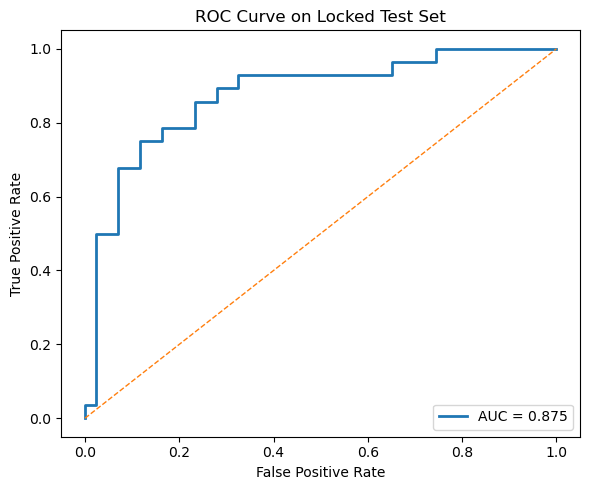

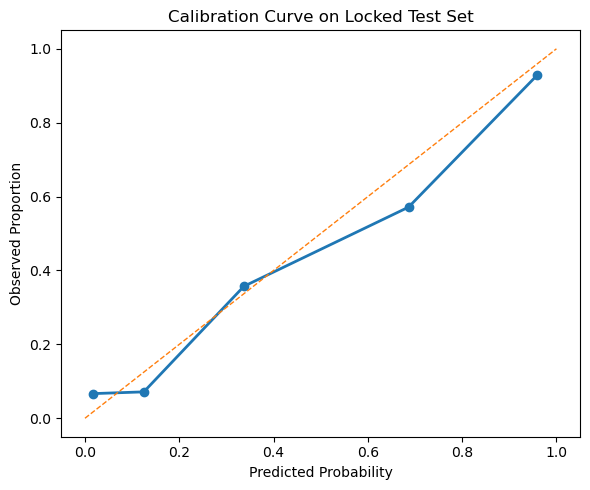

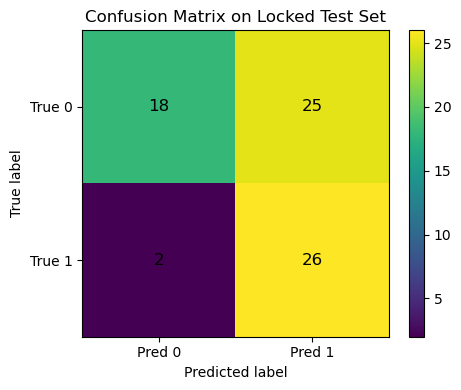

In [21]:
# ======================================
# ✅ 4-1C locked test 최종평가
# - 개발셋 전체로 최종모델 학습
# - locked test는 1회만 평가
# ======================================

final_model = build_final_model(final_model_name, rs=RANDOM_STATE)
final_model.fit(X_dev_final, y_dev)

test_score = get_score(final_model, X_test_final)
test_pred = (test_score >= best_threshold).astype(int)

test_metrics = calc_metrics(y_test, test_pred, test_score)
test_metrics_df = pd.DataFrame([test_metrics])

print("✅ [locked test 1회 최종 성능]")
display(test_metrics_df.round(3))

# bootstrap 95% CI
B = 2000
boot_rows = []
n_test = len(y_test)

for b in range(B):
    idx = np.random.choice(np.arange(n_test), size=n_test, replace=True)
    y_b = y_test.iloc[idx].reset_index(drop=True)
    s_b = pd.Series(test_score[idx])

    # bootstrap 샘플에 클래스 2개 다 없으면 AUC는 NaN 가능
    p_b = (s_b >= best_threshold).astype(int)
    boot_rows.append(calc_metrics(y_b, p_b, s_b))

boot_df = pd.DataFrame(boot_rows)

bootstrap_ci_df = pd.DataFrame({
    "Metric": boot_df.columns,
    "Point_Estimate": [test_metrics[m] for m in boot_df.columns],
    "CI_2.5%": boot_df.quantile(0.025).values,
    "CI_97.5%": boot_df.quantile(0.975).values
})

print("✅ [bootstrap_ci_df] locked test 95% CI")
display(bootstrap_ci_df.round(3))

# -------------------------
# 시각화 1: ROC curve
# -------------------------
fpr, tpr, _ = roc_curve(y_test, test_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {test_metrics['ROC_AUC']:.3f}")
plt.plot([0, 1], [0, 1], "--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Locked Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# -------------------------
# 시각화 2: Calibration curve
# -------------------------
prob_true, prob_pred = calibration_curve(y_test, test_score, n_bins=5, strategy="quantile")

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", lw=2)
plt.plot([0, 1], [0, 1], "--", lw=1)
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration Curve on Locked Test Set")
plt.tight_layout()
plt.show()

# -------------------------
# 시각화 3: Confusion matrix
# -------------------------
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix on Locked Test Set")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

✅ [importance_table] regularized coefficient table


,Feature,Beta,Abs_Beta,Direction
0,student_interact,-1.112,1.112,Negative
1,students_diligent,-0.798,0.798,Negative
2,support_fac,-0.606,0.606,Negative
3,change_major,0.536,0.536,Positive
4,theory_cls,-0.519,0.519,Negative
5,peer_class,-0.378,0.378,Negative
6,study_hard,-0.356,0.356,Negative
7,course_variety,-0.329,0.329,Negative
8,prof_passion,-0.310,0.310,Negative
9,time_eff,-0.228,0.228,Negative


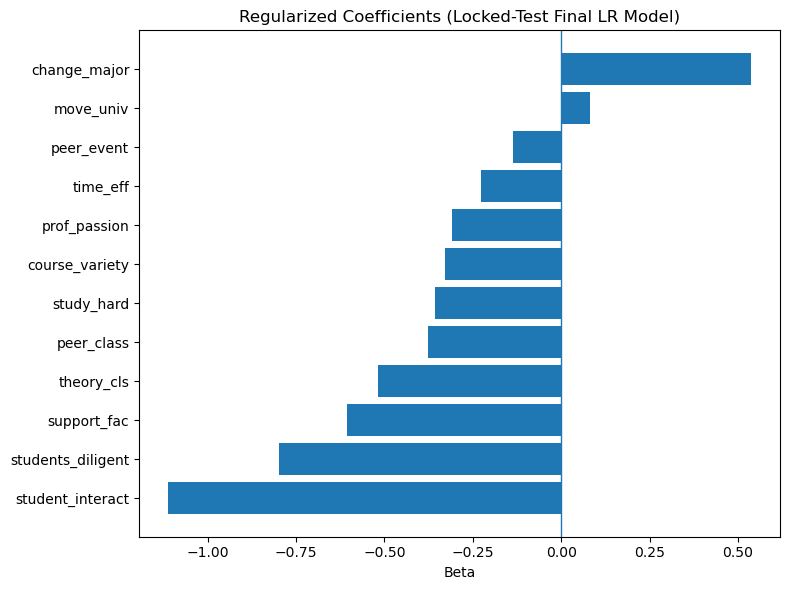

✅ [sm_summary_df] supplementary statsmodels OR table


,Feature,Beta,OR,CI_2.5%,CI_97.5%,p_value
0,change_major,0.535,1.708,1.178,2.476,0.005
1,move_univ,0.062,1.064,0.703,1.611,0.768
2,peer_event,-0.087,0.917,0.535,1.570,0.752
3,time_eff,-0.244,0.783,0.464,1.321,0.359
4,course_variety,-0.312,0.732,0.465,1.151,0.176
5,prof_passion,-0.345,0.708,0.363,1.381,0.311
6,peer_class,-0.379,0.684,0.389,1.204,0.188
7,study_hard,-0.393,0.675,0.413,1.103,0.117
8,theory_cls,-0.543,0.581,0.361,0.934,0.025
9,support_fac,-0.557,0.573,0.388,0.847,0.005


✅ [sign_stability_df]


,Feature,Mean_Beta,Median_Beta,Positive_Ratio,Negative_Ratio,Sign_Stability
0,course_variety,-0.316,-0.320,0.000,1.000,1.000
1,student_interact,-1.138,-1.121,0.000,1.000,1.000
2,students_diligent,-0.777,-0.760,0.000,1.000,1.000
3,theory_cls,-0.528,-0.532,0.000,1.000,1.000
4,prof_passion,-0.309,-0.285,0.000,1.000,1.000
5,peer_class,-0.322,-0.329,0.000,1.000,1.000
6,support_fac,-0.629,-0.608,0.000,1.000,1.000
7,change_major,0.499,0.495,1.000,0.000,1.000
8,study_hard,-0.356,-0.326,0.000,1.000,1.000
9,peer_event,-0.181,-0.169,0.067,0.933,0.933


✅ [vif_df] multicollinearity check


,Feature,VIF
0,peer_event,2.464
1,peer_class,2.408
2,prof_passion,2.305
3,course_variety,1.877
4,theory_cls,1.745
5,students_diligent,1.730
6,student_interact,1.640
7,time_eff,1.522
8,study_hard,1.520
9,move_univ,1.332


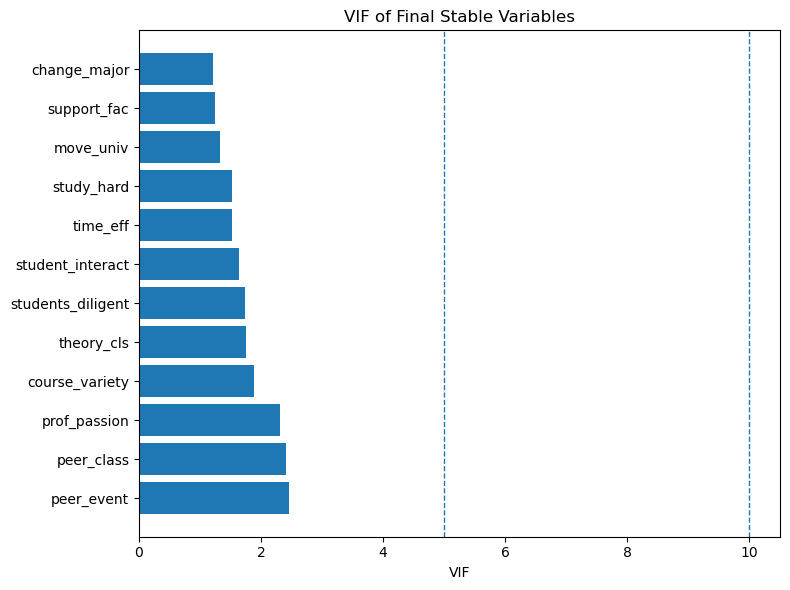

In [22]:
# ======================================
# ✅ 4-1D LR 전용 보조분석
# - regularized coefficient table
# - supplementary statsmodels OR table
# - sign stability
# - VIF
# ======================================

if final_model_name != "LogisticRegression":
    print("현재 최적모델이 LogisticRegression이 아니므로 LR 전용 보조분석은 생략합니다.")
else:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant

    # -------------------------
    # 1) Regularized coefficient table
    # -------------------------
    beta = final_model.named_steps["clf"].coef_.ravel()

    importance_table = pd.DataFrame({
        "Feature": vars_final,
        "Beta": beta,
        "Abs_Beta": np.abs(beta),
        "Direction": np.where(beta >= 0, "Positive", "Negative")
    }).sort_values("Abs_Beta", ascending=False).reset_index(drop=True)

    print("✅ [importance_table] regularized coefficient table")
    display(importance_table.round(3))

    plt.figure(figsize=(8, 6))
    beta_plot = importance_table.sort_values("Beta", ascending=True)
    plt.barh(beta_plot["Feature"], beta_plot["Beta"])
    plt.axvline(0, lw=1)
    plt.title("Regularized Coefficients (Locked-Test Final LR Model)")
    plt.xlabel("Beta")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 2) supplementary statsmodels OR table
    #    - 개발셋 전체 기준, 원척도 OR
    # -------------------------
    X_sm = X_dev_final.copy()
    X_sm = X_sm.apply(lambda s: s.fillna(s.median()), axis=0)
    X_sm_const = sm.add_constant(X_sm, has_constant="add")

    sm_model = sm.Logit(y_dev, X_sm_const).fit(disp=False, maxiter=200)

    sm_summary_df = pd.DataFrame({
        "Feature": sm_model.params.index,
        "Beta": sm_model.params.values,
        "OR": np.exp(sm_model.params.values),
        "CI_2.5%": np.exp(sm_model.conf_int()[0].values),
        "CI_97.5%": np.exp(sm_model.conf_int()[1].values),
        "p_value": sm_model.pvalues.values
    })

    sm_summary_df = sm_summary_df.query("Feature != 'const'").sort_values("OR", ascending=False).reset_index(drop=True)

    print("✅ [sm_summary_df] supplementary statsmodels OR table")
    display(sm_summary_df.round(3))

    # -------------------------
    # 3) sign stability
    #    - 개발셋 반복 분할에서 계수 부호 안정성
    # -------------------------
    sign_rows = []
    coef_collect = []

    for rep in range(30):
        rs = RANDOM_STATE + rep
        X_tr, X_va, y_tr, y_va = train_test_split(
            X_dev_final, y_dev,
            test_size=0.25,
            stratify=y_dev,
            random_state=rs
        )

        rep_model = build_final_model("LogisticRegression", rs=rs)
        rep_model.fit(X_tr, y_tr)
        coef_collect.append(rep_model.named_steps["clf"].coef_.ravel())

    coef_collect = np.vstack(coef_collect)

    sign_stability_df = pd.DataFrame({
        "Feature": vars_final,
        "Mean_Beta": coef_collect.mean(axis=0),
        "Median_Beta": np.median(coef_collect, axis=0),
        "Positive_Ratio": (coef_collect > 0).mean(axis=0),
        "Negative_Ratio": (coef_collect < 0).mean(axis=0),
        "Sign_Stability": np.maximum((coef_collect > 0).mean(axis=0), (coef_collect < 0).mean(axis=0))
    }).sort_values("Sign_Stability", ascending=False).reset_index(drop=True)

    print("✅ [sign_stability_df]")
    display(sign_stability_df.round(3))

    # -------------------------
    # 4) VIF
    # -------------------------
    X_vif = X_dev_final.copy()
    X_vif = X_vif.apply(lambda s: s.fillna(s.median()), axis=0)
    X_vif_const = add_constant(X_vif)

    vif_df = pd.DataFrame({
        "Feature": X_vif_const.columns,
        "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
    })

    vif_df = vif_df.query("Feature != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True)

    print("✅ [vif_df] multicollinearity check")
    display(vif_df.round(3))

    plt.figure(figsize=(8, 6))
    plt.barh(vif_df["Feature"], vif_df["VIF"])
    plt.axvline(5, linestyle="--", lw=1)
    plt.axvline(10, linestyle="--", lw=1)
    plt.title("VIF of Final Stable Variables")
    plt.xlabel("VIF")
    plt.tight_layout()
    plt.show()